<a href="https://colab.research.google.com/github/narendra2006/Pipeline_Silent_Face_Anti-Spoofing/blob/main/pipeline_Silent_Face_Anti_Spoofing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture
# ==============================================================================
# STEP 0: MASTER ENVIRONMENT SETUP (ANTI-NUMPY 2.0 & ANTI-ONNXSCRIPT BUG)
# ==============================================================================

!pip uninstall -y -q onnx onnxscript onnxruntime onnxruntime-gpu insightface numpy
!find /usr/local/lib/python3.*/dist-packages -maxdepth 1 -iname "onnxruntime*" -exec rm -rf {} +
!pip cache purge

# Hapus onnxscript dari daftar instalasi
!pip install -q "opencv-python==4.9.0.80" "onnxruntime==1.18.0" "onnx==1.16.1" \
                "easydict==1.13" "tensorboardX==2.6.2.2" "scikit-image==0.22.0" \
                "cython==3.0.10" "requests==2.32.3" "scipy==1.13.0"

!pip install -q "insightface==1.0.1" --no-deps
!pip install -q "numpy==1.26.4" --force-reinstall --no-cache-dir

**🚨 RESTART SESSION: Pergi ke menu atas Colab > klik Runtime (Sesi Waktu Jalan) > pilih Restart session (Mulai ulang sesi). Langkah ini mengunci versi yang baru diinstal ke dalam memori otak Colab. Langkah selanjutnya tinggal run step 0, 1, 2, dan seterusnya sampai selesai.**

---



## **Step 0: Environment Setup**


---


Tahap inisialisasi workspace, tujuannya mengaitkan Google Drive sebagai sumber dataset, menginstal dependensi yang dibutuhkan, mengunduh repository
Silent Face Anti-Spoofing, dan menyiapkan YuNet dan SCRFD sebagai face detector
utama yang tahan dan kompatibel untuk deployment mobile via ONNX.

In [ ]:
# Menghubungkan Google Drive sebagai sumber dataset dan penyimpanan model.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Mengatur TRESHOLD
THRESHOLD = 0.75

In [ ]:
# Mengunci semua sumber keacakan agar hasil training konsisten.
import os, torch, random, numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Benchmark dinyalakan untuk speed, deterministic dimatikan
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

print(f"Random seed terkunci: {SEED} (cuDNN Benchmark: ON)")

Random seed terkunci: 42 (cuDNN Benchmark: ON)


In [ ]:
import os
import insightface
import urllib.request
from insightface.app import FaceAnalysis

%cd /content

# Clone Repository Silent-Face-Anti-Spoofing
!rm -rf /content/Silent-Face-Anti-Spoofing
!git clone -q https://github.com/narendra2006/Silent-Face-Anti-Spoofing.git

# Mengunduh model YuNet (Detector Utama)
YUNET_PATH = '/content/Silent-Face-Anti-Spoofing/src/yunet.onnx'
YUNET_URL  = (
    'https://github.com/opencv/opencv_zoo/raw/main/'
    'models/face_detection_yunet/face_detection_yunet_2023mar.onnx'
)

if not os.path.exists(YUNET_PATH):
    print(" → Mendownload YuNet (0.23MB)...")
    try:
        # Menggunakan urllib agar error bisa ditangkap
        urllib.request.urlretrieve(YUNET_URL, YUNET_PATH)
        print(" YuNet berhasil diunduh!")
    except Exception as e:
        # Jika gagal, akan masuk ke sini
        print(f" Gagal mendownload YuNet! Error: {e}")
        raise SystemExit("Proses dihentikan karena model utama gagal diunduh.") # Menghentikan eksekusi

# Mengunduh & Inisialisasi model SCRFD (Detector Fallback)
print(" → Mendownload & inisialisasi SCRFD via InsightFace...")
scrfd_app = FaceAnalysis(name='buffalo_s', allowed_modules=['detection'], providers=['CUDAExecutionProvider'])
scrfd_app.prepare(ctx_id=0, det_size=(640, 640))

print(" → Semua model detektor berhasil diunduh dan diinisialisasi!")


/content
 → Mendownload YuNet (0.23MB)...
 YuNet berhasil diunduh!
 → Mendownload & inisialisasi SCRFD via InsightFace...
download_path: /root/.insightface/models/buffalo_s


100%|██████████| 124617/124617 [00:04<00:00, 28111.69KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_s/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_s/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_s/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_s/w600k_mbf.onnx recognition
set det-size: (640, 640)
 → Semua model detektor berhasil diunduh dan diinisialisasi!


In [ ]:
# Memastikan semua komponen yang dibutuhkan sudah siap
import cv2, torch, sys

print("=" * 60)
print(" VERIFIKASI ENVIRONMENT (YUNET + SCRFD)")
print("=" * 60)

# Library
print(f"  OpenCV        : {cv2.__version__}")
print(f"  PyTorch       : {torch.__version__}")
try:
    import insightface
    print(f"  InsightFace   : {insightface.__version__}")
except ImportError:
    print(f"  InsightFace   : Tidak terinstall")

# Hardware
gpu_info = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'
print(f"  GPU           : {gpu_info}")

# Repository Path Configuration
repo_path = '/content/Silent-Face-Anti-Spoofing'
repo_ok = os.path.exists(os.path.join(repo_path, 'src'))

if repo_ok:
    # Hanya masukkan ke sys.path JIKA reponya benar-benar ada
    if repo_path not in sys.path:
        sys.path.append(repo_path)
    print("  Repository    : Ada & masuk sys.path")
else:
    print("  Repository    : Tidak ada")

# Detektor YuNet
if os.path.exists(YUNET_PATH):
    ukuran_kb = os.path.getsize(YUNET_PATH) / 1024
    print(f"  YuNet (L1)    : Ada ({ukuran_kb:.1f} KB)")
else:
    print(f"  YuNet (L1)    : Tidak ada")

# ONNX Runtime (GPU Check)
try:
    import onnxruntime as ort
    providers = ort.get_available_providers()
    gpu_provider = 'CUDAExecutionProvider' in providers
    print(f"  ONNX Runtime  : {ort.__version__} (GPU: {gpu_provider})")
except ImportError:
    print(f"  ONNX Runtime  : Tidak terinstall")

print("=" * 60)

# Status keseluruhan (gpu_provider dihapus dari syarat mutlak)
semua_ok = all([repo_ok, os.path.exists(YUNET_PATH)])

if semua_ok:
    print(" SEMUA KOMPONEN SIAP → Lanjut ke Step 1")
    if not gpu_provider:
        print(" Catatan: ONNX Runtime berjalan di CPU (Sengaja disetting untuk hindari bug Colab, 100% AMAN!)")
else:
    print(" Ada komponen yang belum siap!")

 VERIFIKASI ENVIRONMENT (YUNET + SCRFD)
  OpenCV        : 4.9.0
  PyTorch       : 2.11.0+cu128
  InsightFace   : 1.0.1
  GPU           : Tesla T4
  Repository    : Ada & masuk sys.path
  YuNet (L1)    : Ada (227.1 KB)
  ONNX Runtime  : 1.18.0 (GPU: False)
 SEMUA KOMPONEN SIAP → Lanjut ke Step 1
 Catatan: ONNX Runtime berjalan di CPU (Sengaja disetting untuk hindari bug Colab, 100% AMAN!)


## **Step 1.0: Data Collection**

---
Tahap pengumpulan dataset. Mengambil dataset wajah Asli (Live) dan Palsu (Spoof) dari Google Drive dalam format ZIP, mengekstraknya, lalu
menyusunnya ke dalam struktur folder yang rapi sebagai fondasi pipeline.

In [ ]:
from pathlib import Path
import os, glob, shutil, subprocess

# Direktori utama pipeline
INGESTION_DIR   = '/content/ml_pipeline/01_raw_data'
CLASS_ASLI_DIR  = os.path.join(INGESTION_DIR, 'class_1_asli')
CLASS_SPOOF_DIR = os.path.join(INGESTION_DIR, 'class_0_spoof')
TEMP_BUFFER     = '/content/temp_buffer'

# Lokasi file ZIP di Google Drive
ZIP_PATH_ASLI  = '/content/drive/MyDrive/Dataset Asli Final.zip'
ZIP_PATH_SPOOF = '/content/drive/MyDrive/Dataset Palsu Final.zip'

print(" Konfigurasi path selesai")
print(f" → Asli  : {ZIP_PATH_ASLI}")
print(f" → Spoof : {ZIP_PATH_SPOOF}")

 Konfigurasi path selesai
 → Asli  : /content/drive/MyDrive/Dataset Asli Final.zip
 → Spoof : /content/drive/MyDrive/Dataset Palsu Final.zip


In [ ]:
# Menghapus sisa data dari sesi sebelumnya, agar dataset baru tidak bercampur dengan dataset lama.
TARGET_FOLDERS = [CLASS_ASLI_DIR, CLASS_SPOOF_DIR, TEMP_BUFFER]

print(" Membersihkan folder lama yang masih tersisa")
for folder in TARGET_FOLDERS:
    shutil.rmtree(folder, ignore_errors=True)
    os.makedirs(folder, exist_ok=True)
    print(f" → {folder} (Dibersihkan)")

print(" Semua folder bersih dan siap diisi")

 Membersihkan folder lama yang masih tersisa
 → /content/ml_pipeline/01_raw_data/class_1_asli (Dibersihkan)
 → /content/ml_pipeline/01_raw_data/class_0_spoof (Dibersihkan)
 → /content/temp_buffer (Dibersihkan)
 Semua folder bersih dan siap diisi


In [ ]:
def ekstrak_dataset(zip_path: str, tujuan_dir: str, nama_kelas: str, temp_buffer: str = '/content/temp_buffer'):
    """
    Args:
        zip_path (str): Path sumber file ZIP.
        tujuan_dir (str): Path direktori tujuan untuk meletakkan hasil ekstraksi.
        nama_kelas (str): Label nama kelas/dataset untuk keperluan log.
        temp_buffer (str, optional): Direktori sementara untuk proses ekstraksi.
                                     Default: '/content/temp_buffer'.

    Returns:
        tuple: (jumlah_foto: int, kategori_list: list[str])
    """
    if not os.path.exists(zip_path):
        print(f" File ZIP tidak ditemukan: {zip_path}")
        return 0, []

    # Salin ZIP dari GDrive ke Colab (RAM/Lokal) agar unzip lebih cepat
    print(f" Menyalin {nama_kelas} dari Drive ke Colab...")
    local_zip_path = os.path.join('/content', os.path.basename(zip_path))

    try:
        # Menggunakan shutil.copy2
        shutil.copy2(zip_path, local_zip_path)

        # Ekstrak ke temp buffer
        print(f" Mengekstrak {nama_kelas}...")
        os.makedirs(temp_buffer, exist_ok=True)

        # Menggunakan subprocess.run untuk menangkap error saat unzip
        subprocess.run(['unzip', '-q', local_zip_path, '-d', temp_buffer], check=True)

    except subprocess.CalledProcessError as e:
        print(f" Gagal mengekstrak file ZIP! Detail: {e}")
        shutil.rmtree(temp_buffer, ignore_errors=True)
        return 0, []
    except Exception as e:
        print(f" Terjadi kesalahan sistem: {e}")
        return 0, []
    finally:
        # Hapus zip lokal agar tidak memakan memori Colab
        if os.path.exists(local_zip_path):
            os.remove(local_zip_path)

    # Mencari dan merapikan folder hasil unzip
    semua_file      = glob.glob(os.path.join(temp_buffer, '**', '*.*'), recursive=True)
    jumlah_berhasil = 0
    jumlah_duplikat = 0
    kategori_found  = set()

    # Ekstrak nama folder temp untuk pencarian indeks dinamis
    nama_temp_folder = os.path.basename(temp_buffer).lower()

    for img_path in semua_file:
        if not img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
            continue

        bagian   = Path(img_path).parts
        temp_idx = next(
            (i for i, p in enumerate(bagian) if nama_temp_folder in p.lower()),
            None
        )
        if temp_idx is None:
            continue

        # Ekstraksi nama kategori berdasarkan kedalaman sub-folder
        sisa_path = bagian[temp_idx + 1:]

        if len(sisa_path) == 1:
            kategori = 'lainnya'
        elif len(sisa_path) == 2:
            kategori = sisa_path[0]
        elif len(sisa_path) >= 3:
            kategori = sisa_path[1]
        else:
            continue

        # Normalisasi nama kategori
        kategori_bersih = (
            kategori.lower()
                    .split('(')[0]
                    .strip()
                    .replace(' ', '_')
        )
        kategori_found.add(kategori_bersih)

        # Pindahkan file foto ke tujuan
        dest_folder = os.path.join(tujuan_dir, kategori_bersih)
        os.makedirs(dest_folder, exist_ok=True)

        filename  = os.path.basename(img_path)
        dest_path = os.path.join(dest_folder, filename)

        # Menangani duplikasi nama file menggunakan Counter (Loop While)
        if os.path.exists(dest_path):
            base, ext = os.path.splitext(filename)
            counter = 1
            while os.path.exists(dest_path):
                dest_path = os.path.join(dest_folder, f"{base}_dup{counter}{ext}")
                counter += 1
            jumlah_duplikat += 1

        shutil.move(img_path, dest_path)
        jumlah_berhasil += 1

    # Bersihkan temp buffer
    shutil.rmtree(temp_buffer, ignore_errors=True)

    print(f" {jumlah_berhasil} foto berhasil dipindahkan")
    print(f" Kategori meliputi : {sorted(kategori_found)}")
    if jumlah_duplikat > 0:
        print(f" {jumlah_duplikat} nama file duplikat diamankan dengan counter (_dup1, _dup2, dst)")

    return jumlah_berhasil, sorted(kategori_found)

print(" Fungsi ekstrak_dataset() siap digunakan")

 Fungsi ekstrak_dataset() siap digunakan


In [ ]:
# Menjalankan Ekstraksi Dataset
print("=" * 55)
print(" MEMULAI EKSTRAKSI DATA")
print("=" * 55)

# Menarik Data Kelas Asli (Label 1)
total_asli,  kategori_asli  = ekstrak_dataset(
    ZIP_PATH_ASLI,
    CLASS_ASLI_DIR,
    "Wajah Asli (Live)"
)

print()

# Menarik Data Kelas Palsu (Label 0)
total_spoof, kategori_spoof = ekstrak_dataset(
    ZIP_PATH_SPOOF,
    CLASS_SPOOF_DIR,
    "Wajah Palsu (Spoof)"
)

 MEMULAI EKSTRAKSI DATA
 Menyalin Wajah Asli (Live) dari Drive ke Colab...
 Mengekstrak Wajah Asli (Live)...
 1170 foto berhasil dipindahkan
 Kategori meliputi : ['backlight', 'helm', 'kacamata', 'kombinasi_atribut', 'low_light', 'low_resolution', 'masker', 'normal', 'sudut_jarak']

 Menyalin Wajah Palsu (Spoof) dari Drive ke Colab...
 Mengekstrak Wajah Palsu (Spoof)...
 1170 foto berhasil dipindahkan
 Kategori meliputi : ['backlight', 'helm', 'kacamata', 'kombinasi_atribut', 'low_light', 'low_resolution', 'masker', 'normal', 'sudut_jarak']


In [ ]:
# HASIL & STATUS AKHIR DATA COLLECTION
print("\n" + "=" * 55)
print(" HASIL & STATUS DATA COLLECTION")
print("=" * 55)

# STATISTIK JUMLAH FOTO
print(f"  Class [1] Wajah Asli  : {total_asli:>5} foto")
print(f"  Class [0] Wajah Spoof : {total_spoof:>5} foto")
print(f"  Selisih               : {abs(total_asli - total_spoof):>5} foto")
print("-" * 55)

# RINCIAN KATEGORI
print("  Kategori per kelas:")
print(f"  Asli  ({len(kategori_asli):>2} kategori) : {kategori_asli}")
print(f"  Spoof ({len(kategori_spoof):>2} kategori) : {kategori_spoof}")

hanya_di_asli  = set(kategori_asli)  - set(kategori_spoof)
hanya_di_spoof = set(kategori_spoof) - set(kategori_asli)

if hanya_di_asli or hanya_di_spoof:
    print("") # Spacer
if hanya_di_asli:
    print(f"  ⚠️ Hanya ada di Asli  : {sorted(hanya_di_asli)}")
if hanya_di_spoof:
    print(f"  ⚠️ Hanya ada di Spoof : {sorted(hanya_di_spoof)}")
print("-" * 55)

# EVALUASI KESEIMBANGAN & STATUS
if total_asli == 0 or total_spoof == 0:
    # FATAL: salah satu kelas kosong
    print("   FATAL: SALAH SATU KELAS KOSONG!")
    print("    → Periksa path ZIP dan coba jalankan ulang proses ekstraksi.")

elif abs(total_asli - total_spoof) / max(total_asli, total_spoof) > 0.2:
    # WARNING: dataset tidak seimbang
    kelas_kurang = "Asli" if total_asli < total_spoof else "Spoof"
    rasio = min(total_asli, total_spoof) / max(total_asli, total_spoof)
    print(f"  ⚠️ WARNING: Dataset tidak seimbang (rasio {rasio:.2f}")
    print(f"    → Tambahkan lebih banyak foto kelas: {kelas_kurang}")
    print("     → Atau aktifkan class_weight / augmentasi di step training")

else:
    # SUCCESS: lanjut ke preprocessing
    rasio = min(total_asli, total_spoof) / max(total_asli, total_spoof)
    print(f"  SUCCESS: Dataset seimbang (rasio {rasio:.2f})")
    print("    → Siap lanjut ke Step 2: Preprocessing & Face Detection")

print("=" * 55)
print(f"  Output tersimpan di : {INGESTION_DIR}")
print("=" * 55 + "\n")


 HASIL & STATUS DATA COLLECTION
  Class [1] Wajah Asli  :  1170 foto
  Class [0] Wajah Spoof :  1170 foto
  Selisih               :     0 foto
-------------------------------------------------------
  Kategori per kelas:
  Asli  ( 9 kategori) : ['backlight', 'helm', 'kacamata', 'kombinasi_atribut', 'low_light', 'low_resolution', 'masker', 'normal', 'sudut_jarak']
  Spoof ( 9 kategori) : ['backlight', 'helm', 'kacamata', 'kombinasi_atribut', 'low_light', 'low_resolution', 'masker', 'normal', 'sudut_jarak']
-------------------------------------------------------
  SUCCESS: Dataset seimbang (rasio 1.00)
    → Siap lanjut ke Step 2: Preprocessing & Face Detection
  Output tersimpan di : /content/ml_pipeline/01_raw_data



## **Step 2.0: Data Preprocessing**

---
Tahap preprocessing, mengubah foto mentah menjadi data yang nantinya siap di training.

Setiap foto diproses 3 kali dengan skala yang berbeda-beda (Ensemble Multi Scale):
*   Skala 1.0 → Zoom dekat  : Model belajar tekstur kulit
*   Skala 2.7 → Zoom sedang : Model belajar proporsi kepala
*   Skala 4.0 → Zoom jauh   : Model belajar konteks Latar belakang (layar HP, kertas, dll)

In [ ]:
import cv2, os, glob, sys, shutil
from pathlib import Path
from tqdm import tqdm

# Memastikan Colab membaca skrip dari repositori kloningan
os.chdir('/content/Silent-Face-Anti-Spoofing')
if '/content/Silent-Face-Anti-Spoofing' not in sys.path:
    sys.path.append('/content/Silent-Face-Anti-Spoofing')

from src.anti_spoof_predict import AntiSpoofPredict
from src.generate_patches   import CropImage

# Definisi Arsitektur Multi-scale
SCALE_MAP = {
    1.0: '1_80x80',
    2.7: '2.7_80x80',
    4.0: '4_80x80',
}

SOURCE_ASLI_DIR  = '/content/ml_pipeline/01_raw_data/class_1_asli'
SOURCE_SPOOF_DIR = '/content/ml_pipeline/01_raw_data/class_0_spoof'
BASE_DATASET_DIR = '/content/Silent-Face-Anti-Spoofing/datasets/rgb_image'

# Membersihkan folder hasil crop dari run sebelumnya (jika ada)
print(" Membersihkan folder output lama...")
if os.path.exists(BASE_DATASET_DIR):
    shutil.rmtree(BASE_DATASET_DIR, ignore_errors=True)
print(" → Konfigurasi siap & folder output bersih")

 Membersihkan folder output lama...
 → Konfigurasi siap & folder output bersih


In [ ]:
# [L1] Inisialisasi YuNet
# [L2] SCRFD sudah diinisialisasi di Step 0 sebagai `scrfd_app`
predictor = AntiSpoofPredict(device_id=0)

# Pemotong gambar (Cropper)
image_cropper = CropImage()

print(" Sistem Preprocessing :")
print("   [L1] Detektor Utama    : YuNet (Cepat)")
print("   [L2] Detektor Fallback : SCRFD (Akurat untuk wajah tertutup)")
print("   [L3] Aturan Final      : REJECT (Abaikan gambar full frame)")

 [L1] YuNet siap
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


model ignore: /root/.insightface/models/buffalo_s/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_s/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_s/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_s/w600k_mbf.onnx recognition
set det-size: (640, 640)
 [L2] SCRFD siap
 AntiSpoofPredict siap di device: cuda:0
 Sistem Preprocessing :
   [L1] Detektor Utama    : YuNet (Cepat)
   [L2] Detektor Fallback : SCRFD (Akurat untuk wajah tertutup)
   [L3] Aturan Final     

In [ ]:
def proses_dataset(input_dir: str, label: str, deskripsi: str):
    """
    Mesin pemroses gambar yang mengandalkan Cascade Detection (L1 YuNet -> L2 SCRFD).
    Gambar yang tidak memiliki wajah akan ditolak (REJECT), gambar yang valid akan
    dipotong ke dalam 3 skala (1.0, 2.7, 4.0) untuk memperkuat pemahaman AI.
    """
    # Kumpulkan semua foto beserta kategorinya
    daftar_gambar = []
    subfolders = [f for f in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, f))]

    if subfolders:
        for kategori in subfolders:
            folder = os.path.join(input_dir, kategori)
            for p in glob.glob(os.path.join(folder, '*.*')):
                if p.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                    daftar_gambar.append((p, kategori))
    else:
        for p in glob.glob(os.path.join(input_dir, '*.*')):
            if p.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                daftar_gambar.append((p, 'lainnya'))

    # Buat seluruh struktur folder tujuan sebelum loop
    kategori_unik = set(kat for _, kat in daftar_gambar)
    for folder_name in SCALE_MAP.values():
        for kat in kategori_unik:
            os.makedirs(os.path.join(BASE_DATASET_DIR, folder_name, label, kat), exist_ok=True)

    # Variabel Tracking
    berhasil      = 0
    gagal         = 0
    scrfd_ct      = 0
    log_gagal     = []

    # Proses setiap foto
    for img_path, kategori in tqdm(daftar_gambar, desc=deskripsi, unit="foto"):
        # Baca gambar dengan bendera IMREAD_COLOR untuk kepastian format 3-channel
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)

        # Cek integritas gambar (Rusak atau terlalu kecil untuk dianalisis)
        if img is None or img.shape[0] < 50 or img.shape[1] < 50:
            gagal += 1
            log_gagal.append(f"[Rusak/Kecil] {os.path.basename(img_path)}")
            continue

        try:
            h_img, w_img = img.shape[:2]

            # [L1] Coba deteksi dengan YuNet
            bbox = predictor.get_bbox(img)

            # Paksa menjadi integer agar aman dimasukkan ke fungsi array
            x, y, w, h = map(int, bbox)

            # AntiSpoofPredict melempar nilai (0,0,w,h) full frame jika YuNet gagal mendeteksi
            is_yunet_failed = (x == 0 and y == 0 and w == w_img and h == h_img)

            # [L2] Memanggil SCRFD
            if is_yunet_failed:
                faces = scrfd_app.get(img)

                if len(faces) == 0:
                    # [REJECT] L1 dan L2 gagal. Buang gambar ini.
                    gagal += 1
                    log_gagal.append(f"[DITOLAK] Wajah tidak ditemukan: {os.path.basename(img_path)}")
                    continue
                else:
                    # Ambil Bounding Box dari probabilitas wajah tertinggi(faces[0])
                    box = faces[0].bbox.astype(int)
                    x1, y1, x2, y2 = box[0], box[1], box[2], box[3]

                    # Clipping: Mencegah koordinat keluar batas gambar (Negatif / Over)
                    x1 = max(0, x1)
                    y1 = max(0, y1)
                    x2 = min(w_img, x2)
                    y2 = min(h_img, y2)

                    # Hitung ulang dimensi yang sudah aman
                    w, h = x2 - x1, y2 - y1

                    # Pastikan nilainya murni integer
                    bbox = (int(x1), int(y1), int(w), int(h))
                    scrfd_ct += 1

            # Crop dan Simpan 3 Skala
            for scale, folder_name in SCALE_MAP.items():
                wajah = image_cropper.crop(
                    org_img = img, bbox = bbox, scale = scale,
                    out_w = 80, out_h = 80, crop = True
                )
                tujuan = os.path.join(BASE_DATASET_DIR, folder_name, label, kategori)
                cv2.imwrite(os.path.join(tujuan, f"{Path(img_path).stem}.jpg"), wajah)

            berhasil += 1

        except Exception as e:
            gagal += 1
            log_gagal.append(f"[ERROR] {os.path.basename(img_path)}: {str(e)[:50]}")

    # Statistik deteksi wajah
    print(f"\n   Statistik prapemrosesan ({deskripsi}):")
    print(f"      [L1] Terdeteksi YuNet   : {berhasil - scrfd_ct:>4} foto")
    print(f"      [L2] Diselamatkan SCRFD : {scrfd_ct:>4} foto")
    print(f"      Total Wajah di Tolak    : {gagal:>4} foto")

    # Mengembalikan tuple 3 item agar log_gagal bisa dipanggil dari luar
    return berhasil, gagal, log_gagal

print(" Fungsi proses_dataset() sudah aktif")

 Fungsi proses_dataset() sudah aktif


In [ ]:
import os

print("=" * 60)
print(" MEMULAI PROSES CROP & MULTI-SCALE AUGMENTATION")
print("=" * 60)

# Eksekusi Pemotongan Kelas Asli (Label 1)
print("Mulai memproses Kategori Wajah Asli...")
berhasil_asli, gagal_asli, log_gagal_asli = proses_dataset(
    input_dir=SOURCE_ASLI_DIR,
    label='1',
    deskripsi='Class [1] Wajah Asli'
)

# Eksekusi Pemotongan Kelas Palsu (Label 0)
print("\nMulai memproses Kategori Wajah Spoof...")
berhasil_spoof, gagal_spoof, log_gagal_spoof = proses_dataset(
    input_dir=SOURCE_SPOOF_DIR,
    label='0',
    deskripsi='Class [0] Wajah Spoof'
)

# SIMPAN LOG GAGAL KE FILE .TXT (ERROR TRACING)
# Tentukan folder tujuan penyimpanan
TARGET_LOG_DIR = '/content/anti_spoofing_model_onnx'
os.makedirs(TARGET_LOG_DIR, exist_ok=True)

# Nama file teks log
log_file_path = os.path.join(TARGET_LOG_DIR, 'log_foto_gagal_prep.txt')

with open(log_file_path, 'w', encoding='utf-8') as f:
    f.write("=========================================\n")
    f.write("   LOG FOTO GAGAL DETEKSI/PREPROCESSING\n")
    f.write("=========================================\n\n")

    # Tulis log untuk ASLI
    f.write(f"KATEGORI ASLI (Gagal: {gagal_asli} foto) \n")
    if log_gagal_asli:
        for log in log_gagal_asli:
            f.write(f"{log}\n")
    else:
        f.write("Bagus! Tidak ada foto asli yang gagal.\n")

    f.write("\n") # Jarak spasi

    # Tulis log untuk PALSU
    f.write(f" KATEGORI PALSU (Gagal: {gagal_spoof} foto)\n")
    if log_gagal_spoof:
        for log in log_gagal_spoof:
            f.write(f"{log}\n")
    else:
        f.write("Bagus! Tidak ada foto palsu yang gagal.\n")

print("\n" + "="*50)
print(" PROSES SELESAI!")
print(f" File laporan gagal disimpan di: {log_file_path}")
print("="*50)

 MEMULAI PROSES CROP & MULTI-SCALE AUGMENTATION
Mulai memproses Kategori Wajah Asli...


Class [1] Wajah Asli: 100%|██████████| 1170/1170 [01:54<00:00, 10.25foto/s]



   Statistik prapemrosesan (Class [1] Wajah Asli):
      [L1] Terdeteksi YuNet   : 1092 foto
      [L2] Diselamatkan SCRFD :    6 foto
      Total Wajah di Tolak    :   72 foto

Mulai memproses Kategori Wajah Spoof...


Class [0] Wajah Spoof: 100%|██████████| 1170/1170 [02:33<00:00,  7.63foto/s]


   Statistik prapemrosesan (Class [0] Wajah Spoof):
      [L1] Terdeteksi YuNet   :  954 foto
      [L2] Diselamatkan SCRFD :    0 foto
      Total Wajah di Tolak    :  216 foto

 PROSES SELESAI!
 File laporan gagal disimpan di: /content/anti_spoofing_model_onnx/log_foto_gagal_prep.txt


In [ ]:
# Mencegah pembagian dengan nol jika ada kelas yang kosong
if berhasil_asli > 0 and berhasil_spoof > 0:
    rasio = max(berhasil_asli, berhasil_spoof) / min(berhasil_asli, berhasil_spoof)
    mayoritas = "Asli" if berhasil_asli > berhasil_spoof else "Spoof"
    minoritas = "Spoof" if berhasil_asli > berhasil_spoof else "Asli"
else:
    rasio = float('inf')

total_ok = berhasil_asli + berhasil_spoof
total_gagal = gagal_asli + gagal_spoof

print("\n" + "=" * 60)
print("HASIL AKHIR PREPROCESSING")
print("=" * 60)
print(f" Wajah Asli  → Berhasil: {berhasil_asli:>4} | Dibuang: {gagal_asli:>3}")
print(f" Wajah Spoof → Berhasil: {berhasil_spoof:>4} | Dibuang: {gagal_spoof:>3}")
print(f" {'-' * 42}")
print(f" Total foto diproses : {total_ok + total_gagal:>4}")
print(f" Total file dataset  : {total_ok * 3:>4}  ({total_ok} foto × 3 skala)")
print(f" Total foto dibuang  : {total_gagal:>4}")
print("=" * 60)

# Verifikasi Konsistensi Multi-Skala (Mencegah folder kosong)
print("\nVerifikasi distribusi file per skala:")
semua_valid = True
jumlah_per_label = {'0': berhasil_spoof, '1': berhasil_asli}

for folder_name in SCALE_MAP.values():
    for label in ['0', '1']:
        path = os.path.join(BASE_DATASET_DIR, folder_name, label)
        # Menghitung jumlah file fisik di dalam direktori
        jumlah = sum(len(files) for _, _, files in os.walk(path)) if os.path.exists(path) else 0
        nama = "Asli " if label == '1' else "Spoof"
        acuan = jumlah_per_label[label]
        status = "" if jumlah == acuan else " ⚠️"
        print(f"  {folder_name:<12} {nama:<8} {jumlah:>8}{status}")
        if jumlah != acuan:
            semua_valid = False

# Analisis Keseimbangan Kelas (Class Imbalance)
print("\nAnalisis Keseimbangan Data (Class Balance):")
if rasio == float('inf'):
    print("  ERROR: Salah satu kelas kosong sama sekali! Training dibatalkan.")
elif rasio <= 1.5:
    print(f"  Sangat Baik (Rasio 1 : {rasio:.2f}). Dataset seimbang.")
elif rasio <= 2.0:
    print(f"  Peringatan (Rasio 1 : {rasio:.2f}). Kelas '{mayoritas}' mendominasi.")
    print("  Sistem aman, namun disarankan mengaktifkan Class Weights saat training.")
else:
    print(f"  KRITIS (Rasio 1 : {rasio:.2f}). Imbalance ekstrem (> 1:2.0)!")
    print(f"  Kelas '{mayoritas}' terlalu banyak dibandingkan kelas '{minoritas}'.")
    print("  Wajib gunakan Class Weights atau terapkan Augmentasi pada training set.")

print()
if semua_valid and total_ok > 0 and rasio != float('inf'):
    print(" Semua skala konsisten! Dataset bersih dari Full Frame.")
    print(" SIAP LANJUT KE STEP 3 (Dataset Split & Training)")
else:
    print(" Ada yang tidak konsisten atau data rusak. Periksa log di atas.")


HASIL AKHIR PREPROCESSING
 Wajah Asli  → Berhasil: 1098 | Dibuang:  72
 Wajah Spoof → Berhasil:  954 | Dibuang: 216
 ------------------------------------------
 Total foto diproses : 2340
 Total file dataset  : 6156  (2052 foto × 3 skala)
 Total foto dibuang  :  288

Verifikasi distribusi file per skala:
  1_80x80      Spoof         954
  1_80x80      Asli         1098
  2.7_80x80    Spoof         954
  2.7_80x80    Asli         1098
  4_80x80      Spoof         954
  4_80x80      Asli         1098

Analisis Keseimbangan Data (Class Balance):
  Sangat Baik (Rasio 1 : 1.15). Dataset seimbang.

 Semua skala konsisten! Dataset bersih dari Full Frame.
 SIAP LANJUT KE STEP 3 (Dataset Split & Training)


 Mengambil 6 sampel acak dari direktori skala: [2.7_80x80]...


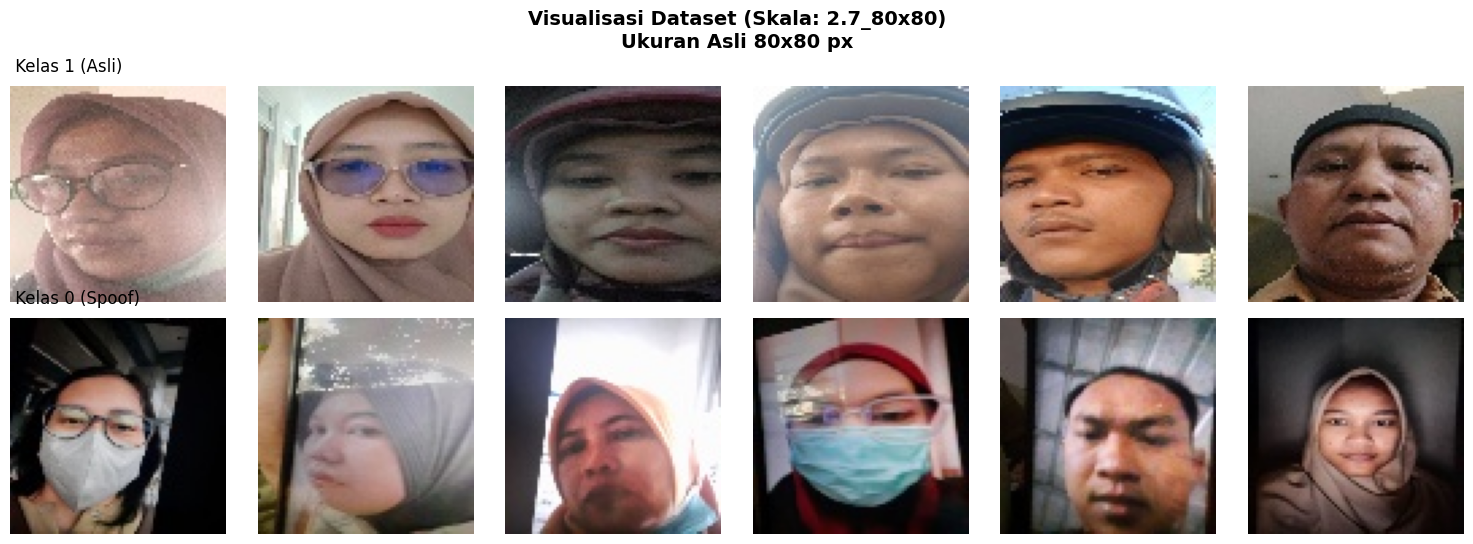

In [ ]:
import os
import glob
import random
import cv2
import matplotlib.pyplot as plt

def visualisasi_sampel_dataset(base_dir, skala='2.7_80x80', jumlah_sampel=5):
    """
    Mengambil dan menampilkan sampel acak gambar Asli dan Spoof.

    Args:
        base_dir (str)    : Direktori utama dataset (BASE_DATASET_DIR)
        skala (str)       : Pilihan skala ('1_80x80', '2.7_80x80', '4_80x80')
        jumlah_sampel (int): Jumlah gambar per baris
    """
    print(f" Mengambil {jumlah_sampel} sampel acak dari direktori skala: [{skala}]...")

    # Kumpulkan semua path gambar menggunakan glob
    # Direktori: base_dir / skala / label(1 atau 0) / kategori / file.jpg
    path_asli = glob.glob(os.path.join(base_dir, skala, '1', '**', '*.*'), recursive=True)
    path_spoof = glob.glob(os.path.join(base_dir, skala, '0', '**', '*.*'), recursive=True)

    # Pastikan ada cukup gambar untuk disampel
    if len(path_asli) < jumlah_sampel or len(path_spoof) < jumlah_sampel:
        print(" Gambar tidak cukup untuk disampel.")
        return

    # Ambil sampel acak
    sampel_asli = random.sample(path_asli, jumlah_sampel)
    sampel_spoof = random.sample(path_spoof, jumlah_sampel)

    # Inisialisasi Kanvas Matplotlib
    fig, axes = plt.subplots(2, jumlah_sampel, figsize=(jumlah_sampel * 2.5, 5.5))
    fig.suptitle(f"Visualisasi Dataset (Skala: {skala})\nUkuran Asli 80x80 px", fontsize=14, fontweight='bold')

    # Plot Wajah Asli (Baris 0)
    for i, img_path in enumerate(sampel_asli):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # BGR ke RGB agar warna normal di Matplotlib
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title(" Kelas 1 (Asli)", fontsize=12, pad=10, loc='left')

    # Plot Wajah Spoof (Baris 1)
    for i, img_path in enumerate(sampel_spoof):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title(" Kelas 0 (Spoof)", fontsize=12, pad=10, loc='left')

    plt.tight_layout()
    plt.show()

# Panggil fungsi (Silakan ubah 'skala' menjadi '1_80x80' atau '4_80x80' untuk melihat bedanya)
visualisasi_sampel_dataset(BASE_DATASET_DIR, skala='2.7_80x80', jumlah_sampel=6)

## **Step 2.5: Split Dataset**

---
Tahap pembagian dataset menjadi 3 bagian:
*   Train (70%) → Data yang dipelajari model saat training
*   Val   (15%) → Data untuk memantau performa saat training berlangsung
*   Test  (15%) → Data yang tidak pernah dilihat model dan hanya dipakai untuk evaluasi akhir

In [ ]:
import os, random, collections

# Direktori Utama
BASE_DATASET_DIR = '/content/Silent-Face-Anti-Spoofing/datasets/rgb_image'

# Proporsi pembagian (total harus = 1.0)
TRAIN_RATIO = 0.70   # 70% → Dipelajari model saat training
VAL_RATIO   = 0.15   # 15% → Evaluasi & perbaikan arah selama training (Validation)
TEST_RATIO  = 0.15   # 15% → Evaluasi akhir metrik (FAR/FRR)

# Definisi Skala (Skala pertama jadi Master)
SCALES = ['1_80x80', '2.7_80x80', '4_80x80']
MASTER_SCALE = SCALES[0]
LABELS = ['0', '1']

# Seed agar hasil split selalu sama
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

print(" Konfigurasi split siap:")
print(f"   Train : {TRAIN_RATIO*100:.0f}%")
print(f"   Val   : {VAL_RATIO*100:.0f}%")
print(f"   Test  : {TEST_RATIO*100:.0f}%")
print(f"   Seed  : {RANDOM_SEED}")

 Konfigurasi split siap:
   Train : 70%
   Val   : 15%
   Test  : 15%
   Seed  : 42


In [ ]:
def generate_split_txt_anti_leakage(base_dir: str):
    print("=" * 65)
    print(" MEMULAI SPLIT DATASET (DUAL-FORMAT ANTI-LEAKAGE + SAFEGUARD)")
    print("=" * 65)

    lines = {'train': [], 'val': [], 'test': []}

    for label in LABELS:
        master_path = os.path.join(base_dir, MASTER_SCALE, label)
        if not os.path.exists(master_path):
            continue

        subfolders = [f for f in os.listdir(master_path) if os.path.isdir(os.path.join(master_path, f))]
        subfolders = subfolders if subfolders else ['']

        for kategori in subfolders:
            folder = os.path.join(master_path, kategori) if kategori else master_path
            semua_file = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png'))]

            if not semua_file:
                continue

            # EKSTRAKSI IDENTITAS & GROUPING
            grup_subjek = collections.defaultdict(list)
            for f in semua_file:
                if label == '1':
                    subjek_id = f.rsplit('_', 1)[-1].rsplit('.', 1)[0]
                else:
                    # AMBIL SELURUH NAMA FILE TANPA EKSTENSI (.jpg/.png)
                    subjek_id = f.rsplit('.', 1)[0]

                kunci_grup = f"L{label}_{subjek_id}"
                grup_subjek[kunci_grup].append(f)

            # PENGUNDIAN IDENTITAS/ORANG
            daftar_subjek = list(grup_subjek.keys())
            random.shuffle(daftar_subjek)

            n_subjek = len(daftar_subjek)

            # Safeguard Distribusi Minimal (Mencegah Validation/Test Kosong)
            if n_subjek >= 3:
                # Paksa minimal 1 grup jika hasil perkalian rasionya 0 (misal 0.6 -> 1)
                n_val  = max(1, int(n_subjek * VAL_RATIO))
                n_test = max(1, int(n_subjek * TEST_RATIO))
                n_train = n_subjek - n_val - n_test

                # Jaga-jaga jika train malah habis (walau tidak mungkin terjadi di ratio 0.7)
                if n_train <= 0:
                    n_train, n_val, n_test = 1, 1, 1
            elif n_subjek == 2:
                n_train, n_val, n_test = 1, 1, 0
            else:
                n_train, n_val, n_test = 1, 0, 0

            subjek_train = set(daftar_subjek[:n_train])
            subjek_val   = set(daftar_subjek[n_train : n_train + n_val])

            # DISTRIBUSI FOTO BERDASARKAN GROUP IDENTITASNYA
            # DISTRIBUSI FOTO BERDASARKAN GROUP IDENTITASNYA
            bagian = {'train': [], 'val': [], 'test': []}
            for f in semua_file:
                if label == '1':
                    subjek_id = f.rsplit('_', 1)[-1].rsplit('.', 1)[0]
                else:
                    # AMBIL SELURUH NAMA FILE TANPA EKSTENSI (.jpg/.png)
                    subjek_id = f.rsplit('.', 1)[0]

                kunci_grup = f"L{label}_{subjek_id}"

                # Masukkan ke himpunan yang sesuai
                if kunci_grup in subjek_train:
                    bagian['train'].append(f)
                elif kunci_grup in subjek_val:
                    bagian['val'].append(f)
                else:
                    bagian['test'].append(f)

            # Tulis ke file TXT untuk semua skala
            for nama_split, daftar_file in bagian.items():
                for f in daftar_file:
                    for scale in SCALES:
                        rel_path = f"{scale}/{label}/{kategori}/{f}" if kategori else f"{scale}/{label}/{f}"
                        lines[nama_split].append(f"{rel_path} {label}\n")

            # Cetak Log
            nama_label = "🟢 Asli " if label == '1' else "🔴 Spoof"
            nama_kat   = kategori if kategori else 'root'
            print(
                f"  {nama_label} | {nama_kat:<15} → "
                f"Total id unik: {n_subjek:<3} | "
                f"Foto: Train={len(bagian['train']):>3}, Val={len(bagian['val']):>3}, Test={len(bagian['test']):>3}"
            )

    # PENGACAKAN FINAL & PENYIMPANAN
    for nama_split in lines:
        random.shuffle(lines[nama_split])
        txt_path = os.path.join(base_dir, f"{nama_split}_list.txt")
        with open(txt_path, 'w') as f:
            f.writelines(lines[nama_split])

    print("\n Eksekusi selesai: train_list.txt, val_list.txt, test_list.txt berhasil di-generate!")

# Jalankan fungsi
generate_split_txt_anti_leakage(BASE_DATASET_DIR)

 MEMULAI SPLIT DATASET (DUAL-FORMAT ANTI-LEAKAGE + SAFEGUARD)
  🔴 Spoof | kacamata        → Total id unik: 83  | Foto: Train= 59, Val= 12, Test= 12
  🔴 Spoof | backlight       → Total id unik: 117 | Foto: Train= 83, Val= 17, Test= 17
  🔴 Spoof | normal          → Total id unik: 162 | Foto: Train=114, Val= 24, Test= 24
  🔴 Spoof | helm            → Total id unik: 117 | Foto: Train= 83, Val= 17, Test= 17
  🔴 Spoof | low_light       → Total id unik: 107 | Foto: Train= 75, Val= 16, Test= 16
  🔴 Spoof | sudut_jarak     → Total id unik: 53  | Foto: Train= 39, Val=  7, Test=  7
  🔴 Spoof | masker          → Total id unik: 85  | Foto: Train= 61, Val= 12, Test= 12
  🔴 Spoof | kombinasi_atribut → Total id unik: 105 | Foto: Train= 75, Val= 15, Test= 15
  🔴 Spoof | low_resolution  → Total id unik: 125 | Foto: Train= 89, Val= 18, Test= 18
  🟢 Asli  | kacamata        → Total id unik: 94  | Foto: Train= 66, Val= 14, Test= 14
  🟢 Asli  | backlight       → Total id unik: 144 | Foto: Train=102, Val= 21,

 Membaca manifesto dari: train_list.txt
 Total baris (Skala 1_80x80) di himpunan train_list.txt: 1452 foto


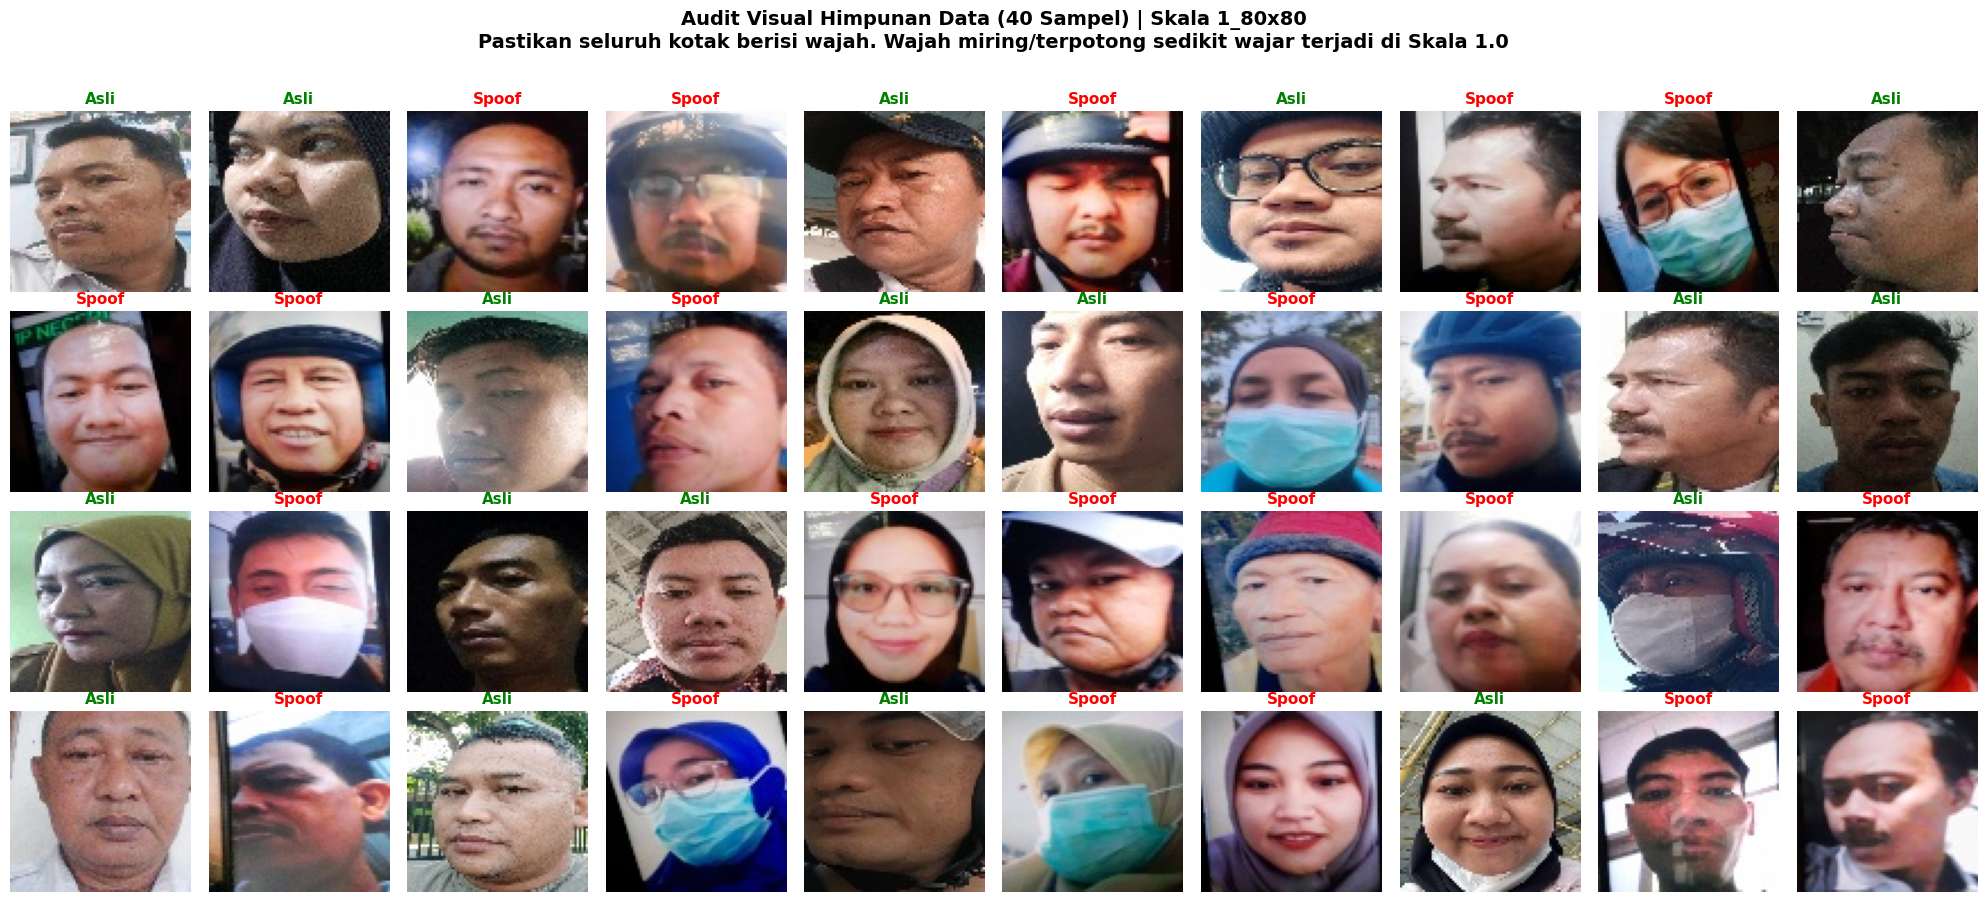

In [ ]:
# TEXT-BASED SPLIT AUDIT & GRID VISUALIZATION
import os, random, cv2
import matplotlib.pyplot as plt

def audit_kualitas_crop_txt(base_dir: str, list_file: str = 'train_list.txt', target_scale: str = '1_80x80', sampel: int = 40):
    """
    Menampilkan grid sampel gambar untuk inspeksi visual BERDASARKAN file .txt.
    Label (Asli), (Spoof).
    """
    txt_path = os.path.join(base_dir, list_file)
    print(f" Membaca manifesto dari: {list_file}")

    if not os.path.exists(txt_path):
        print(f" Error: File {txt_path} tidak ditemukan!")
        return

    # Baca file TXT
    with open(txt_path, 'r') as f:
        semua_baris = f.readlines()

    # Filter baris yang sesuai dengan skala target yang diminta
    baris_terfilter = [b.strip() for b in semua_baris if b.startswith(target_scale)]
    print(f" Total baris (Skala {target_scale}) di himpunan {list_file}: {len(baris_terfilter)} foto")

    if not baris_terfilter:
        print(" Kosong! Tidak ada gambar yang sesuai kriteria.")
        return

    # Tarik sampel acak
    n_sampel = min(sampel, len(baris_terfilter))
    sampel_baris = random.sample(baris_terfilter, n_sampel)

    # Persiapan Grid (10 kolom per baris)
    cols = 10
    rows = (n_sampel + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 2.2))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    # Render Gambar ke Grid
    for i, baris in enumerate(sampel_baris):
        # Ekstrak Path & Label ("1_80x80/1/foto.jpg 1" -> Path, Label)
        parts = baris.rsplit(' ', 1)
        img_rel_path = parts[0]
        label = parts[1]

        img_full_path = os.path.join(base_dir, img_rel_path)
        img = cv2.imread(img_full_path)

        if img is not None:
            axes_flat[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        teks_label = 'Asli' if label == '1' else 'Spoof'
        warna_label = 'green' if label == '1' else 'red'

        axes_flat[i].set_title(teks_label, color=warna_label, fontsize=11, fontweight='bold')
        axes_flat[i].axis('off')

    # Bersihkan sisa kotak kosong di baris terakhir
    for j in range(n_sampel, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.suptitle(
        f'Audit Visual Himpunan Data ({n_sampel} Sampel) | Skala {target_scale}\n'
        'Pastikan seluruh kotak berisi wajah. Wajah miring/terpotong sedikit wajar terjadi di Skala 1.0',
        fontweight='bold', fontsize=14, y=1.02
    )
    plt.tight_layout()
    plt.show()

# Panggil Fungsi (Anda bisa menukar parameter untuk mengecek val_list.txt / test_list.txt)
audit_kualitas_crop_txt(BASE_DATASET_DIR, list_file='train_list.txt', target_scale='1_80x80', sampel=40)

## **Step 2.7: Augmentation**

---
Tahap ini mengolah data gambar ke dalam format tensor agar siap diproses oleh GPU secara cepat dan aman melalui tiga mekanisme utama. Sistem menerapkan augmentasi dinamis seperti rotasi, flip, dan manipulasi kecerahan untuk mencegah overfitting, sehingga AI tetap akurat menghadapi tantangan kondisi nyata seperti posisi HP miring atau cahaya redupn


In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# AUGMENTATION PIPELINE (TRANSFORMS)
# Mensimulasikan kondisi dunia nyata (sudut HP miring, cahaya redup/terang di kantor)
train_transform = transforms.Compose([
    transforms.Resize((80, 80)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),                                # Simulasi kemiringan HP
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Simulasi cahaya ruangan
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standar ImageNet
])

# Validation dan Test dilarang menerima augmentasi (harus murni)
val_test_transform = transforms.Compose([
    transforms.Resize((80, 80)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# FAULT-TOLERANT DATASET CLASS
class FaceSpoofDataset(Dataset):
    """
    Kelas pembaca gambar dinamis. Dilengkapi dengan Fallback Mechanism (gambar hitam)
    untuk memastikan Training Loop di GPU tidak crash di tengah jalan akibat 1-2 file korup.
    """
    def __init__(self, txt_path, base_dir, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().rsplit(' ', 1)
                if len(parts) == 2:
                    self.image_paths.append(parts[0])
                    self.labels.append(int(parts[1]))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = os.path.join(self.base_dir, self.image_paths[idx])

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # Fallback jika terjadi disk I/O error
            print(f"\n⚠️ PERINGATAN: Gagal memuat {os.path.basename(img_path)} | Melewati file ini. Error: {e}")
            image = Image.new('RGB', (80, 80), (0, 0, 0))

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# 3. MULTI-PROCESS DATALOADER (GPU PIPELINE)
BASE_DATASET_DIR = '/content/Silent-Face-Anti-Spoofing/datasets/rgb_image'
BATCH_SIZE = 64

print(" Membangun Saluran Tensor (DataLoader) menuju GPU...")

# Instansiasi Dataset
train_dataset = FaceSpoofDataset(os.path.join(BASE_DATASET_DIR, 'train_list.txt'), BASE_DATASET_DIR, transform=train_transform)
val_dataset   = FaceSpoofDataset(os.path.join(BASE_DATASET_DIR, 'val_list.txt'), BASE_DATASET_DIR, transform=val_test_transform)
test_dataset  = FaceSpoofDataset(os.path.join(BASE_DATASET_DIR, 'test_list.txt'), BASE_DATASET_DIR, transform=val_test_transform)

# Instansiasi DataLoader (Pin Memory = True mempercepat transfer RAM ke VRAM GPU)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(" DataLoader Siap Beroperasi secara Paralel!")
print(f"  └─ Train Loader : {len(train_loader):>4} batch ({len(train_dataset):>5} foto)")
print(f"  └─ Val Loader   : {len(val_loader):>4} batch ({len(val_dataset):>5} foto)")
print(f"  └─ Test Loader  : {len(test_loader):>4} batch ({len(test_dataset):>5} foto)")

 Membangun Saluran Tensor (DataLoader) menuju GPU...
 DataLoader Siap Beroperasi secara Paralel!
  └─ Train Loader :   69 batch ( 4356 foto)
  └─ Val Loader   :   15 batch (  900 foto)
  └─ Test Loader  :   15 batch (  900 foto)


## **Step 3.0: Model Training**

---
sistem membangun rute folder virtual (Symlink) agar repositori bawaan dapat membaca dataset tanpa menggandakan ukuran file di memori. Lalu
melatih 3 model MiniFASNet secara berurutan,
masing-masing menggunakan skala crop yang berbeda.
*   Model 1 → Dilatih dengan data skala 1.0  (zoom dekat)
*   Model 2 → Dilatih dengan data skala 2.7  (zoom sedang)
*   Model 3 → Dilatih dengan data skala 4.0  (zoom jauh)

  
  

In [ ]:
import os
from tqdm import tqdm

BASE_DATASET_DIR = '/content/Silent-Face-Anti-Spoofing/datasets/rgb_image'

print("Membangun struktur folder fisik (via Symlink) untuk repo...")

for split_name in ['train', 'val', 'test']:
    txt_path = os.path.join(BASE_DATASET_DIR, f'{split_name}_list.txt')

    if not os.path.exists(txt_path):
        print(f" File {txt_path} tidak ditemukan, dilewati.")
        continue

    with open(txt_path, 'r') as f:
        lines = f.readlines()

    print(f"\n Menautkan {split_name} ({len(lines)} foto)...")

    for line in tqdm(lines, desc=f"  Proses {split_name}"):
        # Ekstrak path relatif (mengabaikan spasi dan label di akhir baris)
        rel_path = line.strip().rsplit(' ', 1)[0]

        src_path = os.path.join(BASE_DATASET_DIR, rel_path)
        dest_path = os.path.join(BASE_DATASET_DIR, split_name, rel_path)

        # Proses pembuatan tautan (Symlink)
        if os.path.exists(src_path):
            os.makedirs(os.path.dirname(dest_path), exist_ok=True)
            # Validasi agar tidak error file exists jika cell dijalankan ulangi
            if not os.path.exists(dest_path):
                os.symlink(src_path, dest_path)

print("\n Struktur hierarki folder virtual berhasil dibangun!")

Membangun struktur folder fisik (via Symlink) untuk repo...

 Menautkan train (4356 foto)...


  Proses train: 100%|██████████| 4356/4356 [00:00<00:00, 14350.25it/s]



 Menautkan val (900 foto)...


  Proses val: 100%|██████████| 900/900 [00:00<00:00, 20210.70it/s]



 Menautkan test (900 foto)...


  Proses test: 100%|██████████| 900/900 [00:00<00:00, 13456.65it/s]


 Struktur hierarki folder virtual berhasil dibangun!


In [ ]:
%cd /content/Silent-Face-Anti-Spoofing
print(" Memulai training Model 1 (skala 1_80x80)...")
!python train.py --patch_info 1_80x80

/content
 Memulai training Model 1 (skala 1_80x80)...
🔍 Validasi dataset: ./datasets/rgb_image/train/1_80x80
   Class [0] Spoof:   678 foto
   Class [1] Asli :   774 foto
   ───────────────────────────────────
   Total          :  1452 foto
✅ Dataset valid, training siap dimulai

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
lr:  0.001
epochs:  150
milestones:  [60, 100, 130]
epoch 0 started
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:746: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.


In [ ]:
%cd /content/Silent-Face-Anti-Spoofing
print(" Memulai training Model 2 (skala 2.7_80x80)...")
!python train.py --patch_info 2.7_80x80

In [ ]:
%cd /content/Silent-Face-Anti-Spoofing
print(" Memulai training Model 3 (skala 4_80x80)...")
!python train.py --patch_info 4_80x80

In [ ]:
# Memastikan ketiga file .pth tersimpan dengan benar
import glob, os

SKALA_LIST   = ['1_80x80', '2.7_80x80', '4_80x80']
LOG_BASE_DIR = '/content/Silent-Face-Anti-Spoofing/saved_logs'

print("=" * 55)
print(" VERIFIKASI MODEL HASIL TRAINING")
print("=" * 55)

semua_ada = True
for skala in SKALA_LIST:
    # Cari semua file .pth yang mengandung nama skala di dalam folder saved_logs
    models = glob.glob(
        os.path.join(LOG_BASE_DIR, '**', f'*{skala}*.pth'),
        recursive=True
    )
    if models:
        # Ambil file terbaru (berdasarkan Creation Time) jika ada banyak checkpoint
        model_terbaru = max(models, key=os.path.getctime)
        ukuran_mb     = os.path.getsize(model_terbaru) / (1024 * 1024)
        print(f"  ✅ {skala}")
        print(f"     File  : {os.path.basename(model_terbaru)}")
        print(f"     Ukuran: {ukuran_mb:.1f} MB")
    else:
        print(f"  ❌ {skala} — Model tidak ditemukan!")
        semua_ada = False

print("=" * 55)
if semua_ada:
    print(" Semua model tersimpan siap lanjut ke Step 4: Evaluasi")
else:
    print("⚠️  Ada model yang belum selesai jalankan ulang cell training yang gagal")

## **Step 4.0: Setup & Inisialisasi**
---

Persiapan lingkungan evaluasi. Mereload modul src/ agar perubahan terbaru
langsung aktif, menginisialisasi detektor wajah, dan memuat ketiga model
hasil training (.pth) secara otomatis dari folder saved_logs/.

In [ ]:
import os, cv2, sys, glob, random, importlib, warnings
import numpy as np
import matplotlib.pyplot as plt

# Membungkam warning log yang tidak kritis agar output terminal bersih
warnings.filterwarnings('ignore')

#  Pindah ke direktori repo
REPO_DIR = '/content/Silent-Face-Anti-Spoofing'
%cd {REPO_DIR}
if REPO_DIR not in sys.path:
    sys.path.append(REPO_DIR)

#  Import dan Reload Modul Inti
import src.anti_spoof_predict
import src.utility
importlib.reload(src.anti_spoof_predict)
importlib.reload(src.utility)

from src.anti_spoof_predict import AntiSpoofPredict
from src.generate_patches import CropImage

#  Inisialisasi Mesin
predictor = AntiSpoofPredict(device_id=0)  # 0 = GPU
image_cropper = CropImage()
print(" Predictor dan image cropper siap")

#  Cari Model Terbaru
SAVED_LOGS_DIR = '/content/Silent-Face-Anti-Spoofing/saved_logs'

def cari_model_terbaru(nama_skala: str) -> str:
    pattern = os.path.join(SAVED_LOGS_DIR, '**', f'*{nama_skala}*.pth')
    semua_pth = glob.glob(pattern, recursive=True)
    if not semua_pth:
        raise FileNotFoundError(f" Model '{nama_skala}' tidak ditemukan!")
    # Mengunci file dengan creation time (ctime) paling baru
    return max(semua_pth, key=os.path.getctime)

try:
    MODEL_PATHS = {
        1.0: cari_model_terbaru('1_80x80'),
        2.7: cari_model_terbaru('2.7_80x80'),
        4.0: cari_model_terbaru('4_80x80'),
    }

    print("\n DASHBOARD EVALUASI:")
    print("-" * 65)
    for skala, path in MODEL_PATHS.items():
        ukuran_mb = os.path.getsize(path) / (1024 * 1024)
        print(f" └─ Skala {skala}x ➔ {os.path.basename(path):<40} | Size: {ukuran_mb:.2f} MB")
    print("-" * 65)
    print(" Semua model berhasil diambil! Siap melakukan kalkulasi metrik.")

except FileNotFoundError as e:
    print(f"\n {str(e)}")
    print(" Penghentian: Pastikan proses training di Step 3 telah selesai sepenuhnya.")

## **Step 4.5: Quick Test**

---
Uji cepat model dengan 4 foto sampel acak (2 Asli + 2 Spoof) dari raw data.
Bertujuan memastikan pipeline prediksi berjalan tanpa error sebelum evaluasi
formal dijalankan ke seluruh test set.

In [ ]:
import glob, random

def cari_semua_gambar(folder: str) -> list:
    """Mencari seluruh file gambar di dalam folder secara rekursif."""
    hasil = glob.glob(os.path.join(folder, '*.*')) + glob.glob(os.path.join(folder, '**', '*.*'), recursive=True)
    return list(set([p for p in hasil if p.lower().endswith(('.jpg', '.jpeg', '.png')) and os.path.isfile(p)]))

def prediksi_satu_gambar(img_path: str) -> dict:
    """
    Fungsi duplikat arsitektur Backend FastAPI. Menjalankan deteksi Cascade
    dan prediksi Liveness menggunakan Ensemble 3 Skala.
    """
    image = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if image is None: raise ValueError("Gagal membaca foto")

    h_img, w_img = image.shape[:2]

    # [L1] DETEKSI UTAMA (YUNET)
    bbox = predictor.get_bbox(image)

    is_yunet_failed = False
    if bbox is None or len(bbox) < 4:
        is_yunet_failed = True
    else:
        # Pengecekan jatuh ke full frame (YuNet gagal spesifik)
        x, y, w, h = map(int, bbox[:4])
        if x == 0 and y == 0 and w == w_img and h == h_img:
            is_yunet_failed = True

    # [L2] DETEKSI CADANGAN (SCRFD FALLBACK)
    if is_yunet_failed:
        faces = scrfd_app.get(image)
        if len(faces) == 0:
            raise ValueError("Wajah tidak terdeteksi oleh YuNet maupun SCRFD")

        # Konversi format InsightFace [x1,y1,x2,y2] ke format YuNet [x,y,w,h]
        box = faces[0].bbox.astype(int)
        x1, y1 = max(0, box[0]), max(0, box[1])
        x2, y2 = min(w_img, box[2]), min(h_img, box[3])
        bbox = (x1, y1, x2 - x1, y2 - y1)
    else:
        # Jika YuNet berhasil, pastikan tipe datanya murni integer
        bbox = (int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3]))

    # CROP DAN PREDIKSI KEASLIAN
    c1 = image_cropper.crop(image, bbox, 1.0, 80, 80, True)
    c27 = image_cropper.crop(image, bbox, 2.7, 80, 80, True)
    c4 = image_cropper.crop(image, bbox, 4.0, 80, 80, True)

    p1 = predictor.predict(c1, MODEL_PATHS[1.0])
    p27 = predictor.predict(c27, MODEL_PATHS[2.7])
    p4 = predictor.predict(c4, MODEL_PATHS[4.0])

    # Nilai 1 = Probabilitas Asli, Nilai 0 = Probabilitas Spoof
    prob_asli = float(((p1 + p27 + p4) / 3.0)[0][1])

    # Memanggil THRESHOLD langsung dari memori Step 0
    label = 1 if prob_asli >= THRESHOLD else 0
    confidence = prob_asli * 100 if label == 1 else (1 - prob_asli) * 100

    return {
        'image': cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
        'bbox': bbox,
        'label': label,
        'teks_hasil': "ASLI (Live)" if label == 1 else "PALSU (Spoof)",
        'confidence': confidence,
        'warna': 'green' if label == 1 else 'red',
        'detektor_dipakai': 'SCRFD' if is_yunet_failed else 'YuNet'
    }

# PERSIAPAN SAMPEL ACAK
ASLI_DIR  = '/content/ml_pipeline/01_raw_data/class_1_asli'
SPOOF_DIR = '/content/ml_pipeline/01_raw_data/class_0_spoof'

asli_list, spoof_list = cari_semua_gambar(ASLI_DIR), cari_semua_gambar(SPOOF_DIR)

if not asli_list or not spoof_list:
    print("⚠️ Folder data mentah kosong. Lewati visualisasi tes.")
else:
    # Memilih toatl 4 sampel secara acak
    sampel = random.sample(asli_list, min(2, len(asli_list))) + random.sample(spoof_list, min(2, len(spoof_list)))
    fig, axes = plt.subplots(1, len(sampel), figsize=(5 * len(sampel), 6))
    if len(sampel) == 1: axes = [axes]

    for i, img_path in enumerate(sampel):
        # Cadangan visualisasi jika detektor gagal
        try:
            raw_img = cv2.imread(img_path)
            raw_img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB) if raw_img is not None else np.zeros((80,80,3), dtype=np.uint8)
        except Exception:
            raw_img_rgb = np.zeros((80,80,3), dtype=np.uint8)

        # Proses Prediksi AI
        try:
            hasil = prediksi_satu_gambar(img_path)
            vis_img = hasil['image'].copy()
            x, y, w, h = hasil['bbox']

            # Menggambar Bounding Box
            cv2.rectangle(vis_img, (x, y), (x+w, y+h), (0, 255, 0) if hasil['label'] == 1 else (255, 0, 0), 3)

            axes[i].imshow(vis_img)
            axes[i].set_title(
                f"Hasil: {hasil['teks_hasil']}\nConf: {hasil['confidence']:.1f}%\n[{hasil['detektor_dipakai']}]",
                color=hasil['warna'],
                fontweight='bold',
                fontsize=11
            )
        except Exception as e:
            # PENANGANAN ERROR (Tampilkan foto mentah + Pesan Jelas)
            axes[i].imshow(raw_img_rgb) # Tetap tampilkan fotonya

            error_str = str(e).replace("'", "")
            if error_str == "1.0":
                pesan_error = "Memori Model Hilang.\nJalankan ulang Step 4.0"
            else:
                pesan_error = f"{error_str[:35]}..."

            axes[i].set_title(f"❌ Error\n{pesan_error}", color='red', fontsize=10, fontweight='bold')

        axes[i].axis('off')

    plt.suptitle(f"Quick Test Ensemble (Threshold: {THRESHOLD})", fontweight='bold', fontsize=16)
    plt.tight_layout()
    plt.show()

## **Step 4.7: Evaluasi Formal**

---
Mengukur performa model secara kuantitatif menggunakan seluruh test set
data yang tidak pernah dilihat model selama training maupun validasi.
Menghasilkan classification report, AUC-ROC, confusion matrix, serta
dua metrik kritis untuk sistem absensi: FAR (foto palsu lolos) dan
FRR (foto asli ditolak), lengkap dengan verdict kelayakan deployment.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import os, glob, cv2
import matplotlib.pyplot as plt

# Direktori pengujian buta yang sudah di-generate via Symlink di Step 3
TEST_DIR = '/content/Silent-Face-Anti-Spoofing/datasets/rgb_image/test'

def evaluasi_model_formal(test_dir: str):
    """
    Mengeksekusi prediksi pada seluruh data Test Set, mengkalkulasi metrik,
    menggambar Confusion Matrix, dan memberikan rekomendasi kelayakan rilis.
    """
    y_true, y_pred, y_prob = [], [], []
    error_count = 0

    # Pindai kedua kelas secara berurutan (0 = Spoof, 1 = Asli)
    for label_str in ['0', '1']:
        # Kita jadikan skala 1.0 sebagai acuan (anchor) pencarian file
        scale1_dir = os.path.join(test_dir, '1_80x80', label_str)
        if not os.path.exists(scale1_dir): continue

        paths_1 = [p for p in glob.glob(os.path.join(scale1_dir, '**', '*.*'), recursive=True) if p.lower().endswith(('.jpg', '.png'))]
        print(f"Memindai Himpunan Uji Label [{label_str}] ➔ Menemukan {len(paths_1)} foto")

        for p1_path in paths_1:
            # Petakan lokasi file pasangan berskala 2.7 dan 4.0 secara dinamis
            p27_path = p1_path.replace('1_80x80', '2.7_80x80')
            p4_path = p1_path.replace('1_80x80', '4_80x80')

            # Baca matriks ketiga potongan gambar yang sudah siap (tanpa perlu deteksi/crop lagi)
            c1 = cv2.imread(p1_path)
            c27 = cv2.imread(p27_path)
            c4 = cv2.imread(p4_path)

            if c1 is None or c27 is None or c4 is None:
                error_count += 1
                continue

            try:
                # Inferensi paralel 3 model .pth di GPU
                out1 = predictor.predict(c1, MODEL_PATHS[1.0])
                out27 = predictor.predict(c27, MODEL_PATHS[2.7])
                out4 = predictor.predict(c4, MODEL_PATHS[4.0])

                # Hitung rata-rata probabilitas akhir untuk Kelas 1 (Asli)
                prob_asli = float(((out1 + out27 + out4) / 3.0)[0][1])

                y_true.append(int(label_str))
                y_pred.append(1 if prob_asli >= THRESHOLD else 0)
                y_prob.append(prob_asli)
            except Exception as e:
                error_count += 1

    # Proteksi data kosong
    if not y_true:
        print(" Tidak ada data yang berhasil dievaluasi.")
        return

    print("\n" + "=" * 50)
    print(" HASIL EVALUASI MODEL")
    print("=" * 50)

    if error_count > 0:
        print(f"⚠️ Peringatan: Melewati {error_count} file akibat korup atau ketidaklengkapan skala.\n")

    # Cetak Precision, Recall, dan F1-Score
    print(classification_report(y_true, y_pred, target_names=['PALSU (Spoof)', 'ASLI (Live)'], labels=[0, 1]))

    if len(set(y_true)) > 1:
        print(f"🎯 AUC-ROC : {roc_auc_score(y_true, y_prob):.4f}")

    # Visualisasi Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred, labels=[0, 1]), display_labels=['PALSU', 'ASLI'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title('Confusion Matrix — Test Set', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Perhitungan Metrik FAR dan FRR
    n_spoof, n_asli = y_true.count(0), y_true.count(1)
    # FAR = Foto palsu (0) diprediksi lolos sebagai asli (1)
    far = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1) / max(n_spoof, 1)
    # FRR = Wajah asli (1) diprediksi keliru sebagai palsu (0)
    frr = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0) / max(n_asli, 1)

    print("\n" + "-" * 55)
    print(" METRIK KRITIS SISTEM ABSENSI (BIOMETRIC SECURITY)")
    print("-" * 55)
    print(f" → FAR (Foto Palsu Lolos)  : {far*100:>6.2f}%  (Target Industri: < 1.00%)")
    print(f" → FRR (Wajah Asli Ditolak) : {frr*100:>6.2f}%  (Target Industri: < 5.00%)")
    print("-" * 55)

    # VERDICT PRODUCTION READY KELAYAKAN DEPLOYMENT
    print("\n⚠️ KESIMPULAN KELAYAKAN DEPLOYMENTI")
    if far * 100 < 1.0 and frr * 100 < 5.0:
        print("    🟢 [LAYAK DEPLOY] Model memenuhi syarat ketat keamanan biometrik.")
        print("       Aman dari serangan foto/layar dan nyaman digunakan pegawai.")
    elif far * 100 >= 1.0 and frr * 100 < 5.0:
        print("    🔴 [DITOLAK] Celah Keamanan Terdeteksi (FAR Terlalu Tinggi).")
        print(f"       Tingkatkan nilai THRESHOLD (saat ini: {THRESHOLD}) untuk memperketat sistem.")
    else:
        print("    🟡 [PERLU RETRAIN / OPTIMASI] Sistem Terlalu Ketat (FRR Terlalu Tinggi).")
        print(f"       Pegawai asli akan sering ditolak. Coba turunkan sedikit nilai THRESHOLD.")

# Eksekusi fungsi evaluasi formal
evaluasi_model_formal(TEST_DIR)

## **Step 4.9: Analisis Mendalam**

---
Membedah performa model lebih jauh melampaui angka akurasi keseluruhan.
Menampilkan akurasi per kategori kondisi (backlight, masker, helm, dll.),
distribusi confidence score untuk prediksi benar dan salah, serta daftar
lengkap foto yang salah diprediksi dan foto yang membuat model ragu-ragu
(confidence < 70%) sebagai panduan perbaikan dataset.

In [ ]:
import os, glob, cv2
import matplotlib.pyplot as plt

print("=" * 65)
print("MEMULAI DIAGNOSTIK MENDALAM & SIMULASI THRESHOLD")
print("=" * 65)

def analisis_lengkap_dan_threshold(test_dir: str, model_paths: dict):
    """
    Fungsi diagnostik komprehensif untuk membedah titik lemah model AI
    dan mencari nilai Threshold (Ambang Batas) paling optimal untuk produksi.
    """
    hasil_kategori = {}
    distribusi = {'benar_asli': [], 'benar_spoof': [], 'salah_asli': [], 'salah_spoof': []}
    foto_salah, foto_ragu = [], []
    y_true, y_prob = [], []

    # [1] EKSTRAKSI DATA & PREDIKSI
    for label_str in ['0', '1']:
        label_int = int(label_str)
        nama_kelas = "Asli" if label_str == '1' else "Spoof"
        scale1_dir = os.path.join(test_dir, '1_80x80', label_str) # Skala 1.0 sebagai Anchor

        if not os.path.exists(scale1_dir):
            continue

        # Ekstrak sub-folder sebagai kategori kondisi (misal: 'masker', 'backlight')
        subfolders = [f for f in os.listdir(scale1_dir) if os.path.isdir(os.path.join(scale1_dir, f))]
        subfolders = subfolders if subfolders else ['']

        for kategori in subfolders:
            folder = os.path.join(scale1_dir, kategori) if kategori else scale1_dir
            nama_kat = kategori if kategori else 'Umum'
            paths = [p for p in glob.glob(os.path.join(folder, '*.*')) if p.lower().endswith(('.jpg', '.png'))]

            if nama_kat not in hasil_kategori:
                hasil_kategori[nama_kat] = {'benar': 0, 'salah': 0}

            for p1_path in paths:
                p27_path = p1_path.replace('1_80x80', '2.7_80x80')
                p4_path  = p1_path.replace('1_80x80', '4_80x80')

                c1  = cv2.imread(p1_path)
                c27 = cv2.imread(p27_path)
                c4  = cv2.imread(p4_path)

                if c1 is None or c27 is None or c4 is None:
                    continue

                try:
                    p1 = predictor.predict(c1, model_paths[1.0])
                    p2 = predictor.predict(c27, model_paths[2.7])
                    p3 = predictor.predict(c4, model_paths[4.0])

                    prob_asli = float(((p1 + p2 + p3) / 3.0)[0][1])
                    pred_label = 1 if prob_asli >= THRESHOLD else 0
                    confidence = prob_asli * 100 if pred_label == 1 else (1 - prob_asli) * 100

                    benar = (pred_label == label_int)
                    nama_file = os.path.basename(p1_path)

                    y_true.append(label_int)
                    y_prob.append(prob_asli)

                    # Pencatatan Distribusi & Kategori
                    key = ('benar' if benar else 'salah') + '_' + ('asli' if label_int == 1 else 'spoof')
                    distribusi[key].append(confidence)
                    hasil_kategori[nama_kat]['benar' if benar else 'salah'] += 1

                    # Pencatatan Anomali (Salah tebak atau Ragu-ragu)
                    if not benar:
                        foto_salah.append({'file': nama_file, 'kategori': nama_kat, 'kelas': nama_kelas, 'prediksi': 'ASLI' if pred_label == 1 else 'PALSU', 'confidence': confidence})
                    if confidence < 70.0:
                        foto_ragu.append({'file': nama_file, 'kategori': nama_kat, 'kelas': nama_kelas, 'prediksi': 'ASLI' if pred_label == 1 else 'PALSU', 'confidence': confidence, 'benar': benar})
                except Exception:
                    continue

    if not y_true:
        print(" ❌ Error: Tidak ada data yang berhasil dievaluasi.")
        return

    # [2] LAPORAN AKURASI PER KONDISI (KATEGORI)
    print("\n  AKURASI BERDASARKAN KONDISI (KATEGORI)")
    print(f"  {'Kategori':<20} {'Benar':>6} {'Salah':>6} {'Total':>6} {'Akurasi':>9}")
    print("-" * 55)

    akurasi_per_kat = {}
    for kat, data in sorted(hasil_kategori.items()):
        total = data['benar'] + data['salah']
        if total == 0: continue
        akurasi = data['benar'] / total * 100
        akurasi_per_kat[kat] = akurasi
        status_alert = " ⚠️ (Perlu Perbaikan)" if akurasi < 80 else ""
        print(f"  {kat:<20} {data['benar']:>6} {data['salah']:>6} {total:>6} {akurasi:>8.1f}%{status_alert}")

    # [3] RENDER GRAFIK VISUALISASI (4 PANEL)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('In-Depth Model Diagnostics (Anti-Spoofing)', fontweight='bold', fontsize=16, y=0.98)

    # Panel Kiri Atas: Akurasi per Kategori
    if akurasi_per_kat:
        names, vals = list(akurasi_per_kat.keys()), list(akurasi_per_kat.values())
        axes[0,0].bar(names, vals, color=['forestgreen' if v >= 80 else 'darkorange' for v in vals], edgecolor='white')
        axes[0,0].axhline(y=80, color='red', linestyle='--', alpha=0.7)
        axes[0,0].set_title('Akurasi per Kategori', fontweight='bold')
        axes[0,0].tick_params(axis='x', rotation=30)
        axes[0,0].set_ylim(0, 105)

    # Panel Kanan Atas: Distribusi Confidence (Prediksi Benar)
    if distribusi['benar_asli'] or distribusi['benar_spoof']:
        axes[0,1].hist(distribusi['benar_asli'], bins=20, alpha=0.7, color='mediumseagreen', label=f"Asli ({len(distribusi['benar_asli'])})")
        axes[0,1].hist(distribusi['benar_spoof'], bins=20, alpha=0.7, color='royalblue', label=f"Spoof ({len(distribusi['benar_spoof'])})")
        axes[0,1].axvline(x=70, color='red', linestyle='--', label='Batas Ragu (70%)')
        axes[0,1].set_title('Confidence Score — Prediksi BENAR', fontweight='bold')
        axes[0,1].legend()

    # Panel Kiri Bawah: Distribusi Confidence (Prediksi Salah / Kebobolan)
    if distribusi['salah_asli'] or distribusi['salah_spoof']:
        axes[1,0].hist(distribusi['salah_asli'], bins=10, alpha=0.7, color='darkorange', label=f"FRR / Tolak Asli ({len(distribusi['salah_asli'])})")
        axes[1,0].hist(distribusi['salah_spoof'], bins=10, alpha=0.7, color='crimson', label=f"FAR / Kebobolan ({len(distribusi['salah_spoof'])})")
        axes[1,0].set_title('Confidence Score — Prediksi SALAH', fontweight='bold')
        axes[1,0].legend()
    else:
        axes[1,0].text(0.5, 0.5, ' Sempurna!\nTidak ada prediksi salah!', ha='center', va='center', fontsize=16, color='forestgreen', fontweight='bold')
        axes[1,0].axis('off')

    # Panel Kanan Bawah: Rasio Benar vs Salah
    if hasil_kategori:
        names = [k for k, d in sorted(hasil_kategori.items()) if d['benar']+d['salah'] > 0]
        v_benar = [hasil_kategori[k]['benar'] for k in names]
        v_salah = [hasil_kategori[k]['salah'] for k in names]
        x = range(len(names))
        axes[1,1].bar(x, v_benar, label='Tebakan Tepat', color='steelblue')
        axes[1,1].bar(x, v_salah, bottom=v_benar, label='Meleset', color='salmon')
        axes[1,1].set_title('Proporsi Tepat vs Meleset per Kategori', fontweight='bold')
        axes[1,1].set_xticks(list(x))
        axes[1,1].set_xticklabels(names, rotation=30)
        axes[1,1].legend()

    plt.tight_layout(pad=3.0)
    plt.show()

    # [4] SIMULASI THRESHOLD (MENCARI TITIK EMAS FAR vs FRR)
    print("\n" + "=" * 65)
    print(" OPTIMASI THRESHOLD PRODUKSI (SIMULASI FAR vs FRR)")
    print("=" * 65)

    thresholds = [i / 100 for i in range(40, 91, 5)]
    hasil_threshold = []

    for t in thresholds:
        y_pred = [1 if p >= t else 0 for p in y_prob]
        n_spoof, n_asli = y_true.count(0), y_true.count(1)
        far = sum(1 for tr, pr in zip(y_true, y_pred) if tr == 0 and pr == 1) / max(n_spoof, 1)
        frr = sum(1 for tr, pr in zip(y_true, y_pred) if tr == 1 and pr == 0) / max(n_asli, 1)
        acc = sum(1 for tr, pr in zip(y_true, y_pred) if tr == pr) / max(len(y_true), 1)
        hasil_threshold.append({'threshold': t, 'far': far * 100, 'frr': frr * 100, 'akurasi': acc * 100})

    print(f"  {'Threshold':>10} | {'FAR (Lolos)':>12} | {'FRR (Tolak)':>12} | {'Akurasi':>9} | Status")
    print("-" * 75)

    for h in hasil_threshold:
        status = "🟢 Ideal" if h['far'] < 1.0 and h['frr'] < 5.0 else ("🟡 FAR Aman, FRR Tinggi" if h['far'] < 1.0 else ("🟠 Kandidat (FAR < 3%)" if h['far'] < 3.0 else "🔴 Berbahaya"))
        print(f"  {h['threshold']:>10.2f} | {h['far']:>11.1f}% | {h['frr']:>11.1f}% | {h['akurasi']:>8.1f}% | {status}")

    # Mencari Rekomendasi Terbaik (FAR < 1%, dengan FRR terendah)
    kandidat = [h for h in hasil_threshold if h['far'] < 1.0]
    if kandidat:
        terbaik = min(kandidat, key=lambda x: x['frr'])
        print("-" * 75)
        print("  REKOMENDASI DEPLOYMENT:")
        print(f"   Gunakan Threshold : {terbaik['threshold']:.2f}")
        print(f"   Estimasi Performa : FAR {terbaik['far']:.1f}% (Sangat Aman), FRR {terbaik['frr']:.1f}% (Nyaman)")
    else:
        print("-" * 75)
        print(" ⚠️ PERINGATAN: Tidak ada Threshold yang memenuhi standar FAR < 1%.")
        print("    Saran: Kumpulkan lebih banyak data Spoof dan lakukan Retrain model.")

# Eksekusi diagnostik
analisis_lengkap_dan_threshold(TEST_DIR, MODEL_PATHS)

## **Step 5.0: Export ONNX**

---
Tahap export: Mengubah model PyTorch (.pth) menjadi format ONNX
agar bisa dijalankan di Rust via library ort (ONNX Runtime).

Kenapa ONNX?
→ PyTorch tidak bisa langsung dipakai di Rust
→ ONNX adalah format universal yang bisa dibaca
  oleh hampir semua bahasa pemrograman
→ Inference lebih cepat dari PyTorch
→ Tidak butuh GPU di server produksi

In [ ]:
print("⏳ Menyiapkan lingkungan kompilasi ONNX...")

# 1. BERSAHKAN SEMUA VERSI LAMA
!pip uninstall onnxruntime onnxruntime-gpu onnxscript onnx -y -q

# 2. INSTALL VERSI CPU & ONNXSCRIPT DEVELOPER (WAJIB)
!pip install "onnxruntime==1.18.0" "onnx==1.16.1" -q
!pip install git+https://github.com/microsoft/onnxscript.git -q

print("✅ Instalasi Selesai!")
print("🚨 BERHENTI DI SINI! Pergi ke menu atas: Runtime -> Restart session")

In [ ]:
import os, sys, glob, torch, re, shutil
import numpy as np
import onnx
import onnxruntime as ort
from collections import OrderedDict

# ==========================================
# 1. SETUP & REPO BINDING
# ==========================================
REPO_DIR = '/content/Silent-Face-Anti-Spoofing'
%cd {REPO_DIR}
if REPO_DIR not in sys.path:
    sys.path.append(REPO_DIR)

from src.utility import parse_model_name
from src.model_lib.MiniFASNet import MiniFASNetV1SE, MiniFASNetV2

MODEL_DICT = {
    'MiniFASNetV1SE': MiniFASNetV1SE,
    'MiniFASNetV2'  : MiniFASNetV2
}

OUTPUT_DIR = '/content/ml_pipeline/03_onnx_models'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"📦 ONNX Runtime aktif : v{ort.__version__}")

# ==========================================
# 2. FUNGSI PENCARIAN MODEL
# ==========================================
def cari_model_terbaru(nama_skala: str) -> str:
    pattern = f'/content/Silent-Face-Anti-Spoofing/saved_logs/**/*{nama_skala}*.pth'
    semua_pth = glob.glob(pattern, recursive=True)
    if not semua_pth:
        raise FileNotFoundError(f"❌ Model '{nama_skala}' tidak ditemukan.")
    return max(semua_pth, key=os.path.getctime)

MODEL_PATHS = {
    '1_80x80'  : cari_model_terbaru('1_80x80'),
    '2.7_80x80': cari_model_terbaru('2.7_80x80'),
    '4_80x80'  : cari_model_terbaru('4_80x80'),
}

# ==========================================
# 3. FUNGSI EKSPOR ONNX
# ==========================================
def export_ke_onnx(model_path: str, output_dir: str) -> str:
    device     = torch.device('cpu')
    model_name = os.path.basename(model_path)
    h, w, m_type, _ = parse_model_name(model_name)

    print(f"\n" + "─" * 60)
    print(f" ⚙️ MEMPROSES: {model_name}")

    # Memuat & Membersihkan Bobot
    model = MODEL_DICT[m_type](conv6_kernel=(h // 16, w // 16)).to(device)
    sd    = torch.load(model_path, map_location=device)
    clean_sd = OrderedDict()

    for k, v in sd.items():
        if 'FTGenerator' in k: continue
        new_k = k.replace('module.', '').replace('model.', '')
        new_k = re.sub(r'conv_(\d+)\.(\d+)\.', r'conv_\1.model.\2.', new_k)
        new_k = new_k.replace('se_fc1', 'se_module.fc1').replace('se_bn1', 'se_module.bn1')
        new_k = new_k.replace('se_fc2', 'se_module.fc2').replace('se_bn2', 'se_module.bn2')
        clean_sd[new_k] = v

    model.load_state_dict(clean_sd, strict=False)
    model.eval()

    # Ekspor ke ONNX
    if '2.7' in model_name: nama_onnx = 'anti_spoofing_2.7_80x80.onnx'
    elif '4_80x80' in model_name: nama_onnx = 'anti_spoofing_4_80x80.onnx'
    else: nama_onnx = 'anti_spoofing_1_80x80.onnx'

    onnx_path   = os.path.join(output_dir, nama_onnx)
    dummy_input = torch.randn(1, 3, h, w, device=device)

    torch.onnx.export(
        model, dummy_input, onnx_path,
        export_params       = True,
        input_names         = ['input'],
        output_names        = ['output'],
        dynamic_axes        = {'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
        opset_version       = 18,
        do_constant_folding = True
    )
    print(f"    ✅ Graf komputasi diekspor ➔ {nama_onnx}")
    return onnx_path

# ==========================================
# 4. EKSEKUSI BATCH & SIMPAN KE DRIVE
# ==========================================
print("\n" + "=" * 65)
print(" 🚀 MEMULAI KOMPILASI MASSAL (BATCH EXPORT TO ONNX)")
print("=" * 65)

onnx_paths = {}
for skala, pth_path in MODEL_PATHS.items():
    try:
        onnx_paths[skala] = export_ke_onnx(pth_path, OUTPUT_DIR)
    except Exception as e:
        print(f"❌ Gagal kompilasi {skala}: {e}")

DRIVE_OUTPUT = '/content/drive/MyDrive/Anti_Spoofing_Models_ONNX'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)
print("\n" + "=" * 65)
print(" ☁️  MEMADATKAN BOBOT & MENGIRIM KE GOOGLE DRIVE")
print("=" * 65)

total_mb = 0
for skala, path in onnx_paths.items():
    if os.path.exists(path):
        print(f" 🔄 Memadatkan struktur file ➔ {os.path.basename(path)}")
        model_terpisah = onnx.load(path)
        onnx.save(model_terpisah, path)
        mb = os.path.getsize(path) / (1024 * 1024)
        total_mb += mb
        shutil.copy(path, os.path.join(DRIVE_OUTPUT, os.path.basename(path)))
        print(f"  ✅ Tersimpan di Drive: {os.path.basename(path)} ({mb:.2f} MB)")

yunet_src = f'{REPO_DIR}/src/yunet.onnx'
if os.path.exists(yunet_src):
    shutil.copy(yunet_src, os.path.join(DRIVE_OUTPUT, 'yunet.onnx'))
    print(f"  ✅ Tersimpan di Drive: yunet.onnx (Detektor)")

print("\n" + "=" * 32)
print("     PIPELINE MACHINE LEARNING SELESAI     ")
print("=" * 32)